An employee requests leave, and the AI analyzes the request.
Before final approval, a manager (human) must approve or reject it.


**Employee Request**\
**AI Analysis**\
**Human Approval Interrupt**\
**State Change**\
**Database Update Tool**

Import Libaries 


In [1]:
from langgraph.graph import StateGraph , START , END 
from langchain_google_genai import ChatGoogleGenerativeAI
from langgraph.checkpoint.memory import MemorySaver
from langgraph.prebuilt import ToolNode 
from langgraph.graph import add_messages
from typing import TypedDict , Annotated , Literal

from dotenv import load_dotenv
load_dotenv()

f:\AI ML\myvenv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


True

Build LLM

In [2]:
llm = ChatGoogleGenerativeAI(
    model="gemini-3-flash-preview"
)

Build a State

In [3]:
# Custom transducer 

def update_status(current : str , new :str) -> str:
    status_list = {'REQUESTED' , 'UNDER_REVIEW' , 'APPROVED' ,  'REJECTED'}
    if new not in status_list:
        raise ValueError(
            f"Invalid status '{new}'. "
            f"Allowed statuses: {status_list}"
        )

    return new

def update_manager_decision(current : str , new :str) -> str :
    decision_list = { 'APPROVED' , 'REJECTED'}
    if new not in decision_list:
        raise ValueError(  f"Invalid status '{new}'. "
            f"Allowed statuses: {decision_list}"
            )
    return new

In [4]:
class State(TypedDict):
    messages : Annotated[list[str] , add_messages]
    employee_request : str
    start_date : str
    end_date : str
    status : Annotated[str , update_status]
    employee_name: str
    leave_reason: str
    start_date: str
    end_date: str
    ai_summary: str
    ai_recommendation: str
    manager_decision: Annotated[str , update_manager_decision]     
    manager_comments: str

Build tools

In [5]:
# Extract the details form the request 


# Get the updated request from the manager 
def should_continue(state : State) -> Literal['approve_node' , 'rejected_node']:
    if state['manager_decision']  ==  'APPROVED' : return 'approve_node'
    else : return 'rejected_node'
# If success updated the empolee and the database 
def approve_node(state : State) -> State:
    print("Current status" ,  state['status'])
    return {
        "status" : "APPROVED"
    }


# If failded send the rejected summary for the empolyee
def rejected_node(state :State) -> State:
    print("Current Status " , state['status'])
    return {
        "status" : "REJECTED"
    }

def analyze_request(state:State) :
    return state

Build a Agent 

In [6]:
builder = StateGraph(State)

builder.add_node("analyze_request", analyze_request)
builder.add_node("approve_node", approve_node)
builder.add_node("rejected_node", rejected_node)

builder.add_edge(START, "analyze_request")

builder.add_conditional_edges(
    "analyze_request",
    should_continue,
    {
        "approve_node": "approve_node",
        "rejected_node": "rejected_node",
    }
)

builder.add_edge("approve_node", END)
builder.add_edge("rejected_node", END)

memory = MemorySaver()

In [7]:
agent =  builder.compile(checkpointer=memory , interrupt_before=['analyze_request'])

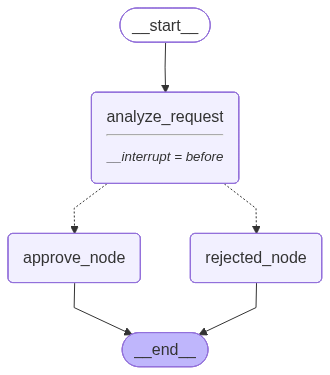

In [8]:
agent

Start the agent streaming 

In [9]:
# Configure with 
config = {
    "configurable" : {
        "thread_id" : "1"
    }
}

In [10]:
for steps in agent.stream({
    "employee_name": "John",
    "leave_reason": "Medical Leave",
    "start_date": "2026-06-10",
    "end_date": "2026-06-12",
    "status": "REQUESTED"} , config=config , stream_mode="values"):
    print(steps)

{'messages': [], 'start_date': '2026-06-10', 'end_date': '2026-06-12', 'status': 'REQUESTED', 'employee_name': 'John', 'leave_reason': 'Medical Leave', 'manager_decision': ''}


Update the status 

In [11]:
agent.update_state(config=config , values=
      {
        "manager_decision": "APPROVED",
        "manager_comments": "Approved by manager"
    
})

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f15dd4e-4c44-6c18-8001-52d29247d65f'}}

In [12]:
agent.get_state(config=config)

StateSnapshot(values={'messages': [], 'start_date': '2026-06-10', 'end_date': '2026-06-12', 'status': 'REQUESTED', 'employee_name': 'John', 'leave_reason': 'Medical Leave', 'manager_decision': 'APPROVED', 'manager_comments': 'Approved by manager'}, next=('analyze_request',), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f15dd4e-4c44-6c18-8001-52d29247d65f'}}, metadata={'source': 'update', 'step': 1, 'parents': {}}, created_at='2026-06-01T16:13:57.771018+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f15dd4b-c625-677a-8000-860433d2ac18'}}, tasks=(PregelTask(id='c81cedc8-8915-2284-d4e3-ccb97cc0bc7a', name='analyze_request', path=('__pregel_pull', 'analyze_request'), error=None, interrupts=(), state=None, result=None),), interrupts=())

In [14]:
for steps in agent.stream(None , config=config, stream_mode="values"):
    print(steps)

{'messages': [], 'start_date': '2026-06-10', 'end_date': '2026-06-12', 'status': 'REQUESTED', 'employee_name': 'John', 'leave_reason': 'Medical Leave', 'manager_decision': 'APPROVED', 'manager_comments': 'Approved by manager'}
{'messages': [], 'start_date': '2026-06-10', 'end_date': '2026-06-12', 'status': 'REQUESTED', 'employee_name': 'John', 'leave_reason': 'Medical Leave', 'manager_decision': 'APPROVED', 'manager_comments': 'Approved by manager'}
Current status REQUESTED
{'messages': [], 'start_date': '2026-06-10', 'end_date': '2026-06-12', 'status': 'APPROVED', 'employee_name': 'John', 'leave_reason': 'Medical Leave', 'manager_decision': 'APPROVED', 'manager_comments': 'Approved by manager'}


In [15]:
state = agent.get_state(config)

In [16]:
state.next

()